In [1]:
from scipy import sparse
import numpy as np
import matplotlib.pyplot as plt
import os
import time

from sklearn.preprocessing import Normalizer, RobustScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
RANDOM_SEED = 42

In [2]:
X = sparse.load_npz("../datasets/clusterization/train.npz")
M, N = X.shape
# масштабируем
scaler = RobustScaler(with_centering=False)
X_scaled = scaler.fit_transform(X)
# PCA
pca_new = PCA(n_components=40)
X_embedded_pca = pca_new.fit_transform(X_scaled)
# NORM
norm = Normalizer()
X_embedded_pca_norm = norm.fit_transform(X_embedded_pca)

### <div align="center">Elbew analyze</div>
С помощью k-MEANS ищу оптимальное количество кластеров и X_embedded_pca

c:\Users\user_1\miniforge3\envs\ipynb_base\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\user_1\AppData\Local\Temp\ipykernel_6544\2693901522.py:22: RuntimeWarning: invalid value encountered in sqrt
  delta_loss_hist[ind] = np.sqrt(loss_hist[ind-1] - loss_hist[ind])


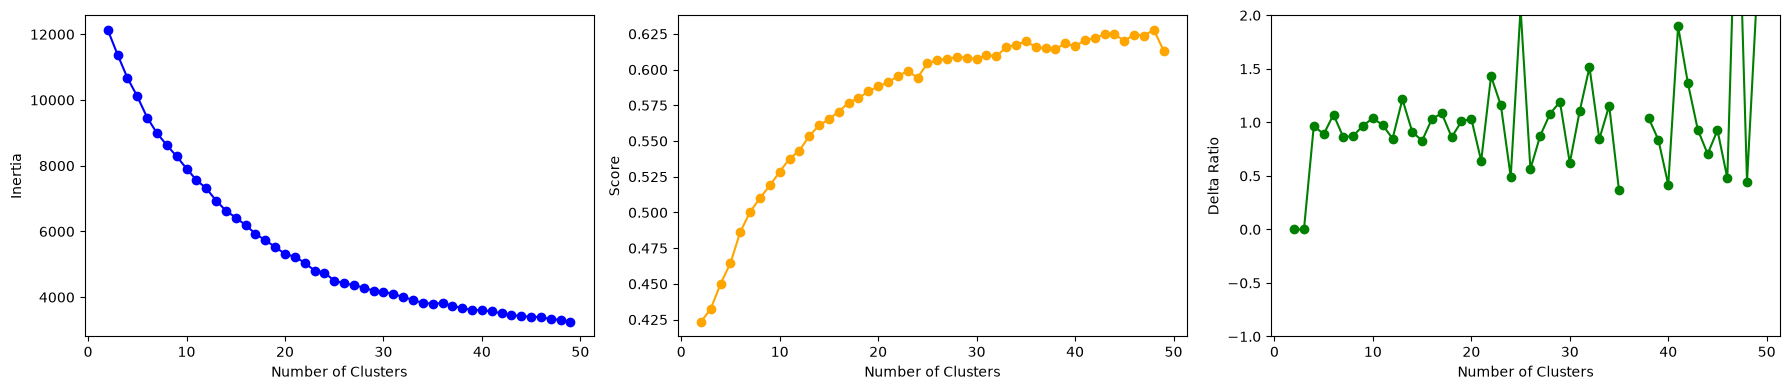

In [3]:
a = 2
b = 50
ln = b-a
loss_hist = np.zeros((ln))
silhouette_hist = np.zeros((ln))
delta_ratio_loss_hist = np.zeros((ln))
delta_loss_hist = np.zeros((ln))

start = time.time()
ind = -1
for k in range(a, b):   
    ind+=1
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20).fit(X_embedded_pca_norm)
    loss_hist[ind] = kmeans.inertia_
    if ind == 0:
        delta_loss_hist[ind] = 0
        delta_ratio_loss_hist[ind] = 0
    elif ind == 1:
        delta_loss_hist[ind] = np.sqrt(loss_hist[ind-1] - loss_hist[ind])
        delta_ratio_loss_hist[ind] = 0
    else:
        delta_loss_hist[ind] = np.sqrt(loss_hist[ind-1] - loss_hist[ind])
        temp = delta_loss_hist[ind]/delta_loss_hist[ind-1]
        if abs(temp) > 10: delta_ratio_loss_hist[ind] = 0
        else: delta_ratio_loss_hist[ind] = temp

    labels = kmeans.labels_
    silhouette_hist[ind] = silhouette_score(X_embedded_pca_norm, labels, random_state=RANDOM_SEED)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))

ax1.plot(np.arange(a, b), loss_hist, marker='o', color="blue")
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')

ax2.plot(np.arange(a, b), silhouette_hist, marker='o', color='orange')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Score')

ax3.plot(np.arange(a, b), delta_ratio_loss_hist, marker='o', color='green')
ax3.set_xlabel('Number of Clusters')
ax3.set_ylabel('Delta Ratio')
ax3.set_ylim(-1, 2)

plt.tight_layout()
plt.show()

#### Conclusion
Анализ показал, что применяя метод подразумевающий выпуклые данные не удаётся достич ситуации при которой увеличение кол-ва кластеров давало бы незначимое улучшение функционала k-means. Это означает, что кластера имеют не сферическую форму. 